#### Tujuan
<small>
Notebook ini bertujuan untuk melakukan preprocessing terhadap seluruh dataset agar memiliki struktur yang sama sebelum digabungkan.

Tahapan yang dilakukan meliputi:

<br> - Membersihkan data.
<br> - Menyamakan nama kolom.
<br> - Melakukan mapping kategori.
<br> - Memilih kolom yang digunakan.
<br> - Menyimpan hasil preprocessing setiap dataset.
</small>

In [46]:
import pandas as pd
import numpy as np
import re
import os

In [47]:
df1 = pd.read_csv("../data/raw/train_transaction_dataset_id.csv")
df2 = pd.read_csv("../data/raw/test_transaction_dataset_id.csv")
df3 = pd.read_csv("../data/raw/Data_Finance_6_Bulan.csv")
df4 = pd.read_csv("../data/raw/transactions_rows.csv")

df5 = pd.read_csv("../data/raw/transport.csv")
df6 = pd.read_csv("../data/raw/transfer.csv")
df7 = pd.read_csv("../data/raw/topup.csv")
df8 = pd.read_csv("../data/raw/donation.csv")
df9 = pd.read_csv("../data/raw/fees.csv")

df10 = pd.read_csv("../data/raw/manual_dataset.csv")

In [48]:
datasets = {
    "Dataset 1": df1,
    "Dataset 2": df2,
    "Dataset 3": df3,
    "Dataset 4": df4,
    "Dataset 5": df5,
    "Dataset 6": df6,
    "Dataset 7": df7,
    "Dataset 8": df8,
    "Dataset 9": df9,
    "Dataset 10": df10,
}

for name, df in datasets.items():
    print("="*50)
    print(name)
    print(df.shape)
    print(df.columns.tolist())

Dataset 1
(357, 2)
['text', 'label']
Dataset 2
(356, 2)
['text', 'label']
Dataset 3
(1199, 6)
['Date', 'Title', 'Amount', 'Type', 'Category', 'Account']
Dataset 4
(20660, 9)
['id', 'user_id', 'amount', 'type', 'category_id', 'description', 'transaction_date', 'created_at', 'updated_at']
Dataset 5
(308, 2)
['text', 'label']
Dataset 6
(323, 2)
['text', 'label']
Dataset 7
(220, 2)
['text', 'label']
Dataset 8
(271, 2)
['text', 'label']
Dataset 9
(270, 2)
['text', 'label']
Dataset 10
(2636, 2)
['text', 'label']


#### Dataset 1

<small>
Preprocessing Dataset 1.
<br> Dataset pertama telah memiliki format `text` dan `label` sehingga tidak memerlukan perubahan struktur.
<br> Tahap yang dilakukan hanya memastikan tidak terdapat missing value maupun duplicate data. </small>

In [49]:
df1 = df1.copy()

df1["label"] = df1["label"].str.lower()

df1["label"] = df1["label"].replace({
    "emi":"loan"
})

df1 = df1.dropna()

df1 = df1.drop_duplicates()

df1 = df1.reset_index(drop=True)

#### Dataset 2

<small>
Preprocessing Dataset 2.
<br> Sama seperti dataset pertama, dataset kedua juga telah memiliki format `text` dan `label` sehingga tidak memerlukan perubahan struktur.
<br> Tahap yang dilakukan hanya memastikan tidak terdapat missing value maupun duplicate data. </small>

In [50]:
df2 = df2.copy()

df2["label"] = df2["label"].str.lower()

df2["label"] = df2["label"].replace({
    "emi":"loan"
})

df2 = df2.dropna()

df2 = df2.drop_duplicates()

df2 = df2.reset_index(drop=True)

#### Dataset 3
<small> Preprocessing Dataset 3.
<br> Dataset ketiga memiliki nama kolom yang berbeda sehingga perlu dilakukan standarisasi.
<br> Kolom **Title** diubah menjadi **text**, sedangkan **Category** diubah menjadi **label**.
</small>

In [51]:
df3 = df3[
    [
        "Title",
        "Category"
    ]
]

In [52]:
df3.columns = [
    "text",
    "label"
]

In [53]:
df3["label"] = df3["label"].str.lower()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9248\1809652995.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["label"] = df3["label"].str.lower()


In [54]:
mapping3 = {
    "makan & minum":"food",
    "belanja":"shopping",
    "hiburan":"entertainment",
    "tagihan":"bills",
    "gaji":"income",
    "goals":"investment"
}

df3["label"] = df3["label"].replace(mapping3)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9248\3776622111.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["label"] = df3["label"].replace(mapping3)


In [55]:
valid_labels = [
    "food",
    "shopping",
    "travel",
    "transport",
    "bills",
    "entertainment",
    "healthcare",
    "education",
    "loan",
    "investment",
    "income",
    "transfer",
    "topup",
    "donation",
    "fees"
]

df3 = df3[df3["label"].isin(valid_labels)]

In [56]:
df3 = df3.dropna()

df3 = df3.drop_duplicates()

df3 = df3.reset_index(drop=True)

### Dataset 4

<small>
Preprocessing Dataset 4.
<br> Dataset keempat memiliki kolom **description** dan **category_id**.
<br> Kolom **description** diubah menjadi **text**, sedangkan **category_id** dipetakan menjadi label kategori agar sesuai dengan dataset lainnya.</small>

In [57]:
df4 = df4[
    [
        "description",
        "category_id"
    ]
]

In [58]:
df4.columns = [
    "text",
    "label"
]

In [59]:
mapping4 = {
    1:"food",
    2:"transport",
    3:"entertainment",
    4:"shopping",
    5:"healthcare",
    6:"bills"
}

df4["label"] = df4["label"].replace(mapping4)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9248\698711344.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4["label"] = df4["label"].replace(mapping4)


In [60]:
df4 = df4.dropna()

df4 = df4.drop_duplicates()

df4["label"] = df4["label"].str.lower()

df4 = df4.reset_index(drop=True)

#### Dataset tambahan

In [61]:
extra = [
    df5,
    df6,
    df7,
    df8,
    df9,
    df10
]

for df in extra:

    df["label"] = df["label"].str.lower()

    df["label"] = df["label"].replace({
        "emi":"loan",
        "ewallet":"topup",
        "charity":"donation",
        "admin_fee":"fees"
    })

    df = df[df["label"].isin(valid_labels)]

    df.dropna(inplace=True)

    df.drop_duplicates(inplace=True)

    df.reset_index(drop=True, inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9248\3786170555.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9248\3786170555.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [62]:
processed = []

for df in extra:
    df = df.copy()
    df["label"] = df["label"].str.lower()
    df["label"] = df["label"].replace({
        "emi":"loan",
        "ewallet":"topup",
        "charity":"donation",
        "admin_fee":"fees"
    })
    df = df[df["label"].isin(valid_labels)]
    df = df.dropna().drop_duplicates().reset_index(drop=True)
    processed.append(df)

df5, df6, df7, df8, df9, df10 = processed

#### Verifikasi Hasil Preprocessing

<small>Tahap ini dilakukan untuk memastikan seluruh dataset telah memiliki struktur yang sama sebelum digabungkan.</small>

In [63]:
datasets = [
    df1,df2,df3,df4,
    df5,df6,df7,df8,df9,df10
]

for i,df in enumerate(datasets,1):

    print("="*50)

    print(f"Dataset {i}")

    print(df.shape)

    print(df.columns.tolist())

    print(sorted(df["label"].unique()))

Dataset 1
(356, 2)
['text', 'label']
['food', 'investment', 'loan', 'shopping', 'travel']
Dataset 2
(356, 2)
['text', 'label']
['food', 'investment', 'loan', 'shopping', 'travel']
Dataset 3
(32, 2)
['text', 'label']
['bills', 'entertainment', 'food', 'income', 'investment', 'shopping']
Dataset 4
(40, 2)
['text', 'label']
['bills', 'entertainment', 'food', 'healthcare', 'shopping', 'transport']
Dataset 5
(209, 2)
['text', 'label']
['transport']
Dataset 6
(322, 2)
['text', 'label']
['transfer']
Dataset 7
(220, 2)
['text', 'label']
['topup']
Dataset 8
(219, 2)
['text', 'label']
['donation']
Dataset 9
(159, 2)
['text', 'label']
['fees']
Dataset 10
(2015, 2)
['text', 'label']
['bills', 'donation', 'education', 'entertainment', 'food', 'healthcare', 'income', 'loan', 'shopping', 'topup', 'transfer', 'transport', 'travel']


In [64]:
print(df1.shape)
print(df2.shape)
print(df3.shape)
print(df4.shape)
print(df5.shape)
print(df6.shape)
print(df7.shape)
print(df8.shape)

(356, 2)
(356, 2)
(32, 2)
(40, 2)
(209, 2)
(322, 2)
(220, 2)
(219, 2)


In [65]:
print(df1["label"].value_counts())

print(df2["label"].value_counts())

print(df3["label"].value_counts())

print(df4["label"].value_counts())

print(df5["label"].value_counts())

print(df6["label"].value_counts())

print(df7["label"].value_counts())

print(df8["label"].value_counts())

label
travel        75
investment    75
food          73
shopping      69
loan          64
Name: count, dtype: int64
label
shopping      85
food          83
travel        70
loan          69
investment    49
Name: count, dtype: int64
label
bills            7
food             7
shopping         6
entertainment    4
income           4
investment       4
Name: count, dtype: int64
label
food             8
transport        8
bills            7
shopping         6
entertainment    6
healthcare       5
Name: count, dtype: int64
label
transport    209
Name: count, dtype: int64
label
transfer    322
Name: count, dtype: int64
label
topup    220
Name: count, dtype: int64
label
donation    219
Name: count, dtype: int64


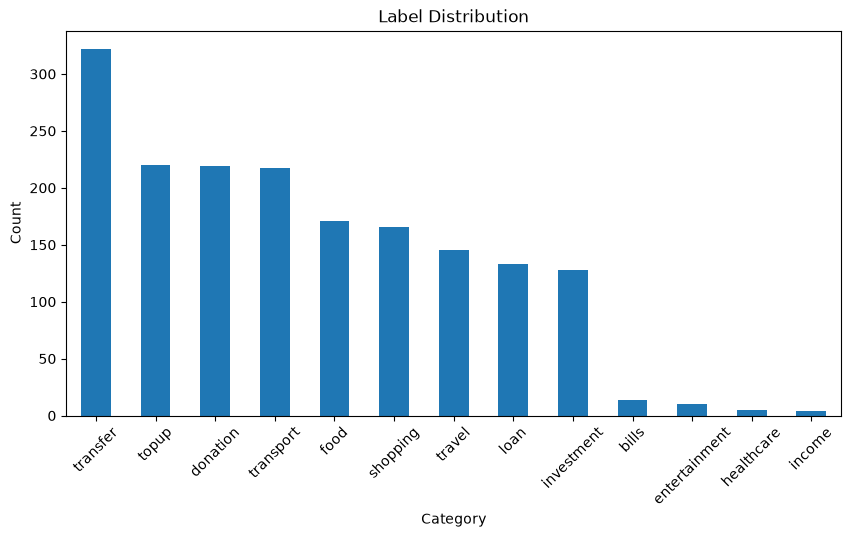

In [66]:
import matplotlib.pyplot as plt

label_counts = pd.concat([
    df1["label"],
    df2["label"],
    df3["label"],
    df4["label"],
    df5["label"],
    df6["label"],
    df7["label"],
    df8["label"]
]).value_counts()

plt.figure(figsize=(10,5))
label_counts.plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [67]:
os.makedirs("../data/processed", exist_ok=True)

df1.to_csv("../data/processed/train_clean.csv", index=False)
df2.to_csv("../data/processed/test_clean.csv", index=False)
df3.to_csv("../data/processed/finance_clean.csv", index=False)
df4.to_csv("../data/processed/transaction_clean.csv", index=False)

df5.to_csv("../data/processed/transport_clean.csv", index=False)
df6.to_csv("../data/processed/transfer_clean.csv", index=False)
df7.to_csv("../data/processed/topup_clean.csv", index=False)
df8.to_csv("../data/processed/donation_clean.csv", index=False)
df9.to_csv("../data/processed/fees_clean.csv", index=False)

df10.to_csv("../data/processed/manual_clean.csv", index=False)

Menyimpan Dataset

<small> Dataset hasil preprocessing disimpan agar dapat digunakan pada proses integrasi data. </small>